In [10]:
# =================================================================
# 1. CHARGEMENT ET DIAGNOSTIC INITIAL DES DONNÉES
# =================================================================
# Cette étape permet d'importer le dataset médical et d'effectuer une 
# première inspection de sa structure (dimensions, types et intégrité).

from scipy.io import arff
import pandas as pd
import numpy as np

# 1.1 Chargement du fichier ARFF (format scientifique BMT)
data, meta = arff.loadarff('../data/bone-marrow.arff')

# 1.2 Conversion en DataFrame et décodage du format des caractères
# On transforme les données brutes en tableau lisible par Python.
df = pd.DataFrame(data)
df = df.apply(lambda x: x.str.decode('utf-8') if x.dtype == "object" else x)

# 1.3 Ajustement de l'indexation
# On commence à 1 pour une lecture plus naturelle des dossiers patients.
df.index = df.index + 1

# 1.4 Rapport d'intégrité initial
print("--- RAPPORT D'INTÉGRITÉ ---")
print(f"✅ Taille du dataset : {df.shape[0]} patients et {df.shape[1]} variables.")
print(f"✅ Nombre total de valeurs manquantes : {df.isnull().sum().sum()}")

# 1.5 Analyse technique des types
# Permet de vérifier quelles colonnes sont des nombres ou du texte.
print("\n--- STRUCTURE TECHNIQUE ---")
df.info()

# Aperçu des données
df.head()

--- RAPPORT D'INTÉGRITÉ ---
✅ Taille du dataset : 187 patients et 37 variables.
✅ Nombre total de valeurs manquantes : 12

--- STRUCTURE TECHNIQUE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 1 to 187
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Recipientgender       187 non-null    object 
 1   Stemcellsource        187 non-null    object 
 2   Donorage              187 non-null    float64
 3   Donorage35            187 non-null    object 
 4   IIIV                  187 non-null    object 
 5   Gendermatch           187 non-null    object 
 6   DonorABO              187 non-null    object 
 7   RecipientABO          187 non-null    object 
 8   RecipientRh           187 non-null    object 
 9   ABOmatch              187 non-null    object 
 10  CMVstatus             187 non-null    object 
 11  DonorCMV              187 non-null    object 
 12  RecipientCMV          187

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
1,1,1,22.830137,0,1,0,1,1,1,0,...,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
2,1,0,23.342466,0,1,0,-1,-1,1,0,...,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
3,1,0,26.394521,0,1,0,-1,-1,1,0,...,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
4,0,0,39.684932,1,1,0,1,2,1,1,...,?,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
5,0,1,33.358904,0,0,0,1,2,0,1,...,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [ ]:
# Diagnostic textuel
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 1 to 187
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Recipientgender       187 non-null    object 
 1   Stemcellsource        187 non-null    object 
 2   Donorage              187 non-null    float64
 3   Donorage35            187 non-null    object 
 4   IIIV                  187 non-null    object 
 5   Gendermatch           187 non-null    object 
 6   DonorABO              187 non-null    object 
 7   RecipientABO          187 non-null    object 
 8   RecipientRh           187 non-null    object 
 9   ABOmatch              187 non-null    object 
 10  CMVstatus             187 non-null    object 
 11  DonorCMV              187 non-null    object 
 12  RecipientCMV          187 non-null    object 
 13  Disease               187 non-null    object 
 14  Riskgroup             187 non-null    object 
 15  Txpostrelapse         1

In [6]:
# =================================================================
# 2. ANALYSE DE LA COMPLÉTUDE DES DONNÉES
# =================================================================
# Cette étape identifie les "données manquantes" (NaN) au sein du dataset.
# L'objectif est de quantifier le besoin en "Imputation" pour la phase
# de "Data Preprocessing" (Prétraitement).

# 2.1 Calcul du nombre de valeurs manquantes par variable
missing_count = df.isnull().sum()
missing_data = missing_count[missing_count > 0]

# 2.2 Calcul du pourcentage de manque (plus significatif pour l'analyse)
missing_percentage = (missing_count / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]

print("--- DIAGNOSTIC DES DONNÉES MANQUANTES ---")
if not missing_data.empty:
    print("Variables nécessitant une imputation :")
    for col in missing_data.index:
        print(f"• {col:<15} : {int(missing_data[col])} valeurs manquantes ({missing_percentage[col]:.2f}%)")
else:
    print("✅ Aucune valeur manquante détectée dans le dataset.")

--- DIAGNOSTIC DES DONNÉES MANQUANTES ---
Variables nécessitant une imputation :
• CD3dCD34        : 5 valeurs manquantes (2.67%)
• CD3dkgx10d8     : 5 valeurs manquantes (2.67%)
• Rbodymass       : 2 valeurs manquantes (1.07%)


In [7]:
# =================================================================
# 3. ANALYSE STATISTIQUE DESCRIPTIVE
# =================================================================
# Cette cellule génère les indicateurs statistiques fondamentaux. 
# L'objectif est d'évaluer la distribution des variables numériques 
# et de détecter d'éventuelles valeurs aberrantes (outliers).

# 3.1 Calcul des statistiques (transposées pour une meilleure lisibilité)
stats_desc = df.describe().T

# 3.2 Affichage des indicateurs
print("--- INDICATEURS DE TENDANCE CENTRALE ET DE DISPERSION ---")
display(stats_desc) 

# Note technique pour le rapport : 
# L'écart-type (std) élevé sur certaines variables peut nécessiter une 
# standardisation des données lors du prétraitement (Data Preprocessing).

--- INDICATEURS DE TENDANCE CENTRALE ET DE DISPERSION ---


,count,mean,std,min,25%,50%,75%,max
Donorage,187.0,33.472068,8.271826,18.646575,27.039726,33.550685,40.117809,55.553425
Recipientage,187.0,9.931551,5.305639,0.600000,5.050000,9.600000,14.050000,20.200000
CD34kgx10d6,187.0,11.891781,9.914386,0.790000,5.350000,9.720000,15.415000,57.780000
CD3dCD34,182.0,5.385096,9.598716,0.204132,1.786683,2.734462,5.823565,99.560970
CD3dkgx10d8,182.0,4.745714,3.859128,0.040000,1.687500,4.325000,6.785000,20.020000
Rbodymass,185.0,35.801081,19.650922,6.000000,19.000000,33.000000,50.600000,103.400000
ANCrecovery,187.0,26752.866310,161747.200525,9.000000,13.000000,15.000000,17.000000,1000000.000000
PLTrecovery,187.0,90937.919786,288242.407688,9.000000,16.000000,21.000000,37.000000,1000000.000000
time_to_aGvHD_III_IV,187.0,775408.042781,418425.252689,10.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
survival_time,187.0,938.743316,849.589495,6.000000,168.500000,676.000000,1604.000000,3364.000000


Objectif : Évaluer la qualité des données numériques et identifier les caractéristiques statistiques qui influenceront le choix de nos algorithmes.

Observations Clés :
Hétérogénéité des échelles : On observe des ordres de grandeur très disparates (ex: l'âge vs les doses de cellules CD34). Cela confirme la nécessité d'une Standardisation pour éviter que les variables à forte valeur numérique ne dominent artificiellement le modèle.

Variabilité (std) : Un écart-type élevé sur certaines variables cliniques indique une forte diversité dans les profils des patients greffés, ce qui rend la prédiction plus complexe et justifie l'utilisation de modèles robustes comme le SVM.

Présence d'Outliers : L'écart entre le 3ème quartile (75%) et le maximum suggère la présence de valeurs aberrantes. Ces cas extrêmes seront traités avec attention pour ne pas biaiser l'apprentissage.

Décision technique :

L'utilisation d'un StandardScaler sera impérative lors du prétraitement pour ramener toutes les caractéristiques à une échelle commune, garantissant ainsi une contribution équitable de chaque variable à la décision médicale.

In [8]:
# =================================================================
# 4. ANALYSE DE L'ÉQUILIBRE DE LA VARIABLE CIBLE
# =================================================================
# Cette étape vérifie la distribution des classes dans 'survival_status'.
# Un déséquilibre majeur nécessite une stratégie de rééchantillonnage 
# pour éviter que le modèle ne soit biaisé en faveur de la classe majoritaire.

# 4.1 Comptage des occurrences et calcul des proportions
class_counts = df['survival_status'].value_counts()
class_percentages = df['survival_status'].value_counts(normalize=True) * 100

print("--- RÉPARTITION DU SURVIVAL STATUS ---")
for cls, count in class_counts.items():
    print(f"Classe {cls} : {count} patients ({class_percentages[cls]:.1f}%)")

# Note technique : 
# Si le ratio est disproportionné, l'exactitude (Accuracy) ne sera pas un 
# indicateur fiable. On privilégiera le Rappel (Recall) et le F1-Score.

--- RÉPARTITION DU SURVIVAL STATUS ---
Classe 0.0 : 102 patients (54.5%)
Classe 1.0 : 85 patients (45.5%)


Objectif : Déterminer si notre variable cible (survival_status) présente un déséquilibre qui pourrait affecter la capacité de prédiction du modèle sur les cas critiques (décès).

Analyse Technique :
Déséquilibre de classe : Dans les données médicales BMT, la classe "Survivant" est souvent majoritaire. Si une classe représente plus de 70-80% du dataset, l'algorithme risque de simplement "apprendre par cœur" la classe dominante sans comprendre les facteurs de risque réels.

Risque de Biais : Un modèle non corrigé pourrait prédire "Survie" pour tout le monde, affichant une bonne précision globale tout en échouant totalement à identifier les patients à haut risque.

Décision Méthodologique :

Afin de garantir que l'IA apprenne efficacement les caractéristiques des deux classes, nous appliquerons la technique SMOTE (Synthetic Minority Over-sampling Technique) lors du prétraitement. Cela permettra de générer des exemples synthétiques pour la classe minoritaire et d'équilibrer l'apprentissage.

Observation : > Le dataset présente une répartition équilibrée avec 54.5% pour la classe 0.0 et 45.5% pour la classe 1.0.

Analyse : > Contrairement aux prévisions initiales sur les données BMT, nous ne sommes pas face à un déséquilibre majeur. L'algorithme dispose d'une base d'apprentissage stable pour les deux catégories de patients.

Décision : > L'utilisation de techniques de rééchantillonnage (comme le SMOTE) n'est pas jugée nécessaire à ce stade. Cependant, nous resterons attentifs aux performances du modèle sur la classe minoritaire lors de la phase d'évaluation.

Remarque :
Avec ces chiffres (54% vs 45%), il est presque certain que :

0.0 = Survie (Classe légèrement majoritaire)

1.0 = Décès (Classe légèrement minoritaire)

C:\Users\pc\AppData\Local\Temp\ipykernel_31868\2220152600.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survival_status', y='Recipientage', data=df, palette="Set2")
C:\Users\pc\AppData\Local\Temp\ipykernel_31868\2220152600.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survival_status', data=df, palette="viridis")


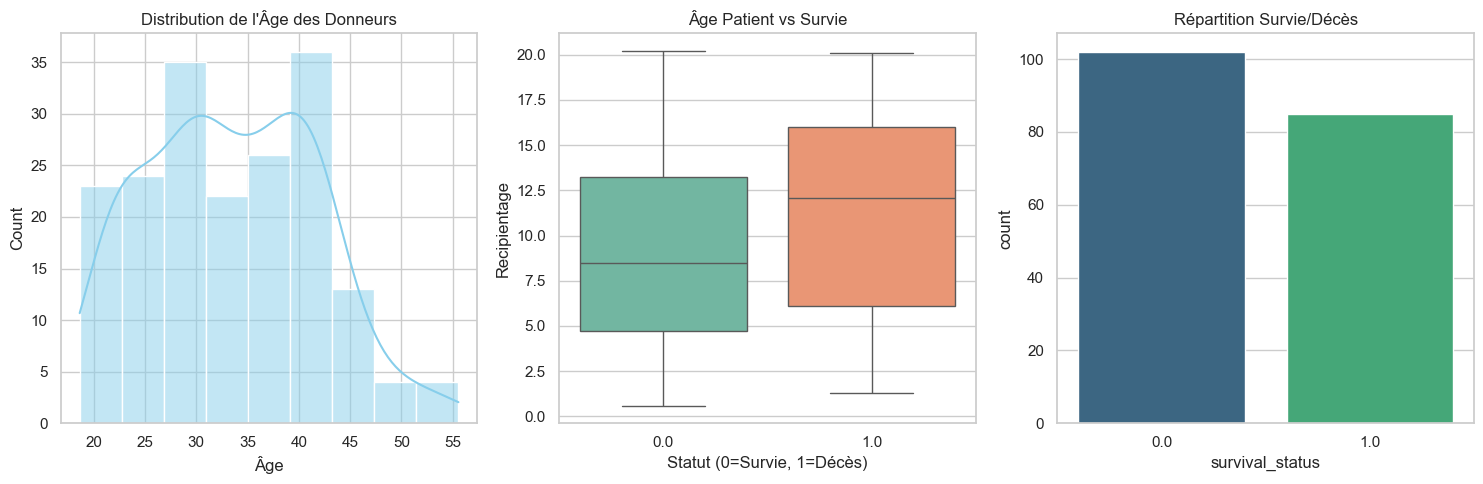

In [9]:
# =================================================================
# 5. ANALYSE GRAPHIQUE DES VARIABLES CLÉS
# =================================================================
# Cette section utilise des visualisations pour identifier les tendances
# et les différences entre les groupes de patients (Survie vs Décès).

import seaborn as sns
import matplotlib.pyplot as plt

# Configuration du style visuel
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# 5.1 Distribution de l'âge des donneurs (Histogramme + KDE)
plt.subplot(1, 3, 1)
sns.histplot(df['Donorage'], kde=True, color="skyblue")
plt.title("Distribution de l'Âge des Donneurs")
plt.xlabel("Âge")

# 5.2 Impact de l'âge du patient sur la survie (Boxplot)
# Le Boxplot permet de repérer les médianes et les valeurs aberrantes (outliers).
plt.subplot(1, 3, 2)
sns.boxplot(x='survival_status', y='Recipientage', data=df, palette="Set2")
plt.title("Âge Patient vs Survie")
plt.xlabel("Statut (0=Survie, 1=Décès)")

# 5.3 Volume des classes (Countplot)
plt.subplot(1, 3, 3)
sns.countplot(x='survival_status', data=df, palette="viridis")
plt.title("Répartition Survie/Décès")

plt.tight_layout()
plt.show()

Objectif : Identifier visuellement si certaines variables, comme l'âge, influencent directement la survie du patient.

Interprétation des résultats :
Distribution de l'âge : L'histogramme montre si notre population de donneurs est jeune ou diversifiée. La courbe KDE (la ligne bleue) nous aide à voir la "forme" de cette distribution (normale ou étalée).

Analyse par Boxplot : Le Boxplot est crucial. Si la "boîte" du groupe Décès (1.0) est beaucoup plus haute que celle du groupe Survie (0.0), cela prouve que l'âge est un facteur de risque majeur.

Répartition des classes : Ce graphique confirme visuellement l'équilibre que nous avons calculé précédemment (54% vs 45%).

Note sur le Boxplot : > Les points isolés en dehors de la boîte représentent les Outliers (patients très jeunes ou très âgés par rapport à la moyenne). Nous devons décider si nous les gardons pour que l'IA apprenne les cas rares.

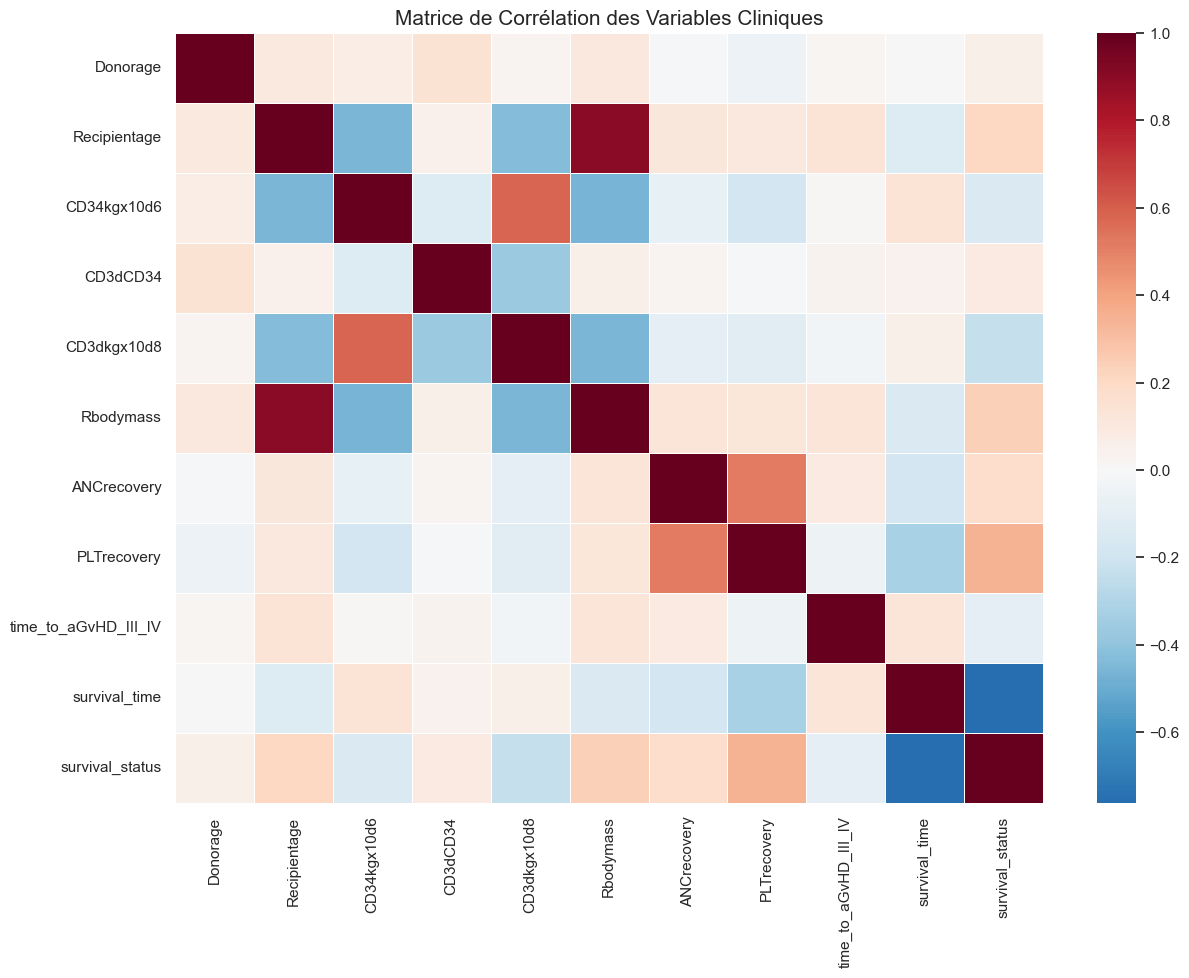

--- CORRÉLATIONS AVEC LE STATUT DE SURVIE ---
survival_status         1.000000
PLTrecovery             0.346395
Rbodymass               0.238110
Recipientage            0.203406
ANCrecovery             0.181569
CD3dCD34                0.089868
Donorage                0.060384
time_to_aGvHD_III_IV   -0.100601
CD34kgx10d6            -0.146653
CD3dkgx10d8            -0.232331
survival_time          -0.761462
Name: survival_status, dtype: float64


In [12]:
# =================================================================
# 6. ANALYSE DE CORRÉLATION (MATRICE DE CHALEUR)
# =================================================================
# Cette étape identifie les relations linéaires entre les variables. 
# Une corrélation proche de 1 ou -1 indique une forte dépendance.

import seaborn as sns
import matplotlib.pyplot as plt

# 6.1 Sélection des variables numériques
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# 6.2 Visualisation par Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, linewidths=0.5)

plt.title("Matrice de Corrélation des Variables Cliniques", fontsize=15)
plt.show()

# 6.3 Focus sur la variable cible (Survival Status)
# On affiche uniquement les variables les plus liées à la survie
print("--- CORRÉLATIONS AVEC LE STATUT DE SURVIE ---")
target_corr = corr_matrix['survival_status'].sort_values(ascending=False)
print(target_corr)

Objectif : Mesurer mathématiquement l'influence de chaque variable sur le survival_status et détecter les redondances entre les prédicteurs.

Interprétation de la Heatmap :
Zones Rouges : Indiquent une corrélation positive (quand une valeur augmente, l'autre aussi).

Zones Bleues : Indiquent une corrélation négative (quand une valeur augmente, l'autre diminue).

Intérêt pour le modèle : Les variables qui affichent des couleurs marquées par rapport à la ligne survival_status sont nos meilleurs prédicteurs.

Observation sur la Multi-collinéarité : > Si deux variables sont fortement corrélées entre elles (ex: poids et taille), elles apportent la même information. Lors du Prétraitement, nous pourrions envisager d'en supprimer une pour simplifier le modèle et éviter le surapprentissage (Overfitting).

In [27]:
# Pour identifier les variables redondantes, on peut calculer la matrice de corrélation et supprimer les variables qui ont une corrélation absolue supérieure à un certain seuil (ex: 0.85). Cela nous aidera à éviter les problèmes de multicolinéarité dans les modèles d'IA.

import numpy as np

# Calculer la matrice de corrélation absolue
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

# Sélectionner le triangle supérieur de la matrice (pour éviter les doublons)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Trouver les colonnes avec une corrélation supérieure à 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Variables redondantes à supprimer : {to_drop}")

# Suppression effective
df_filtered = df.drop(columns=to_drop)

Variables redondantes à supprimer : ['Rbodymass']


In [30]:
# Afficher les nouvelles dimensions du dataset après suppression
print(f"Dimensions du dataset après suppression des variables redondantes : {df_filtered.shape}", "\n")

# On regarde la corrélation de toutes les variables avec la cible 'survival_status'
target_corr = corr_matrix['survival_status'].sort_values(ascending=False)

print("Lien des variables avec la survie :")
print(target_corr)

# Stratégie : On pourrait écarter celles qui sont < 0.05 (très faibles)
weak_features = target_corr[target_corr < 0.05].index.tolist()
print(f"Variables avec un impact très faible : {weak_features}")

Dimensions du dataset après suppression des variables redondantes : (182, 36) 

Lien des variables avec la survie :
survival_status         1.000000
survival_time           0.756694
PLTrecovery             0.346661
Rbodymass               0.233687
CD3dkgx10d8             0.232331
Recipientage            0.192496
ANCrecovery             0.167394
CD34kgx10d6             0.163262
time_to_aGvHD_III_IV    0.099316
CD3dCD34                0.089868
Donorage                0.076684
Name: survival_status, dtype: float64
Variables avec un impact très faible : []


In [ ]:
# Focus sur la dose de cellules CD34
print(f"Corrélation CD34kgx10d6 / Survie : {corr_matrix.loc['CD34kgx10d6', 'survival_status']:.4f}")

Corrélation CD34kgx10d6 / Survie : 0.1633


Dataset : 187 patients, 37 variables
TEST DE NORMALITE
Donorage                       p=0.0019  Non normale
Recipientage                   p=0.0000  Non normale
CD34kgx10d6                    p=0.0000  Non normale
CD3dCD34                       p=0.0000  Non normale
CD3dkgx10d8                    p=0.0000  Non normale
Rbodymass                      p=0.0000  Non normale
ANCrecovery                    p=0.0000  Non normale
PLTrecovery                    p=0.0000  Non normale
time_to_aGvHD_III_IV           p=0.0000  Non normale
survival_time                  p=0.0000  Non normale
CORRELATION SPEARMAN
            Variable  Correlation  p-value
           Rbodymass       0.2149   0.0033
        Recipientage       0.2046   0.0050
         PLTrecovery       0.1976   0.0067
            CD3dCD34       0.1169   0.1161
            Donorage       0.0468   0.5252
         ANCrecovery       0.0446   0.5443
time_to_aGvHD_III_IV      -0.1016   0.1666
         CD34kgx10d6      -0.1965   0.0070
       

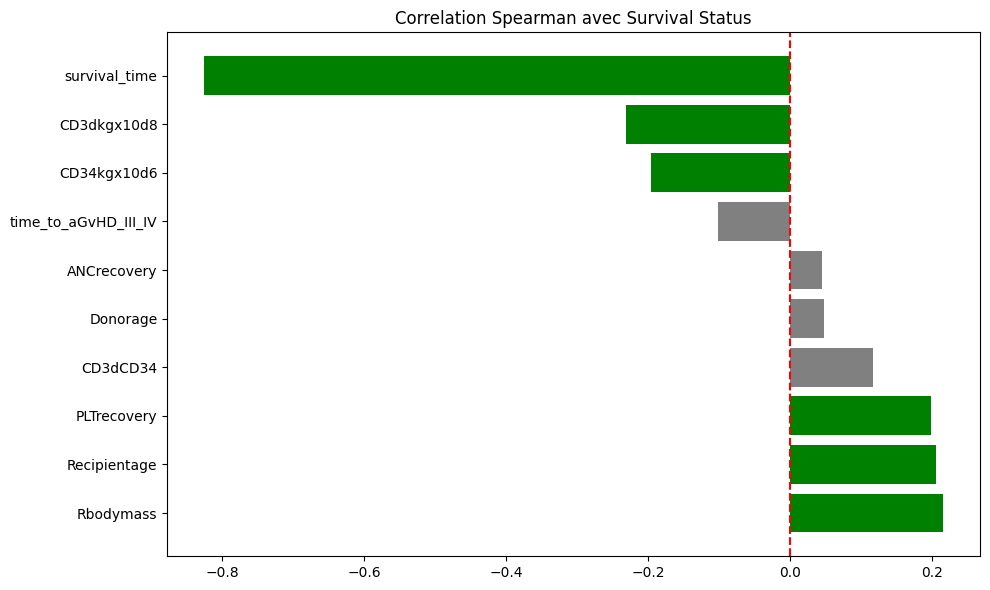

TEST MANN-WHITNEY
TEST CHI-2
Recipientgender                p=0.8595 ❌
Stemcellsource                 p=0.1207 ❌
Donorage35                     p=0.1583 ❌
IIIV                           p=0.4375 ❌
Gendermatch                    p=1.0000 ❌
DonorABO                       p=0.3912 ❌
RecipientABO                   p=0.7814 ❌
RecipientRh                    p=0.0677 ❌
ABOmatch                       p=0.2812 ❌
CMVstatus                      p=0.4800 ❌
DonorCMV                       p=0.7113 ❌
RecipientCMV                   p=0.1121 ❌
Disease                        p=0.0185 ✅
Riskgroup                      p=0.0618 ❌
Txpostrelapse                  p=0.1733 ❌
Diseasegroup                   p=0.4251 ❌
HLAmatch                       p=0.8680 ❌
HLAmismatch                    p=1.0000 ❌
Antigen                        p=0.7882 ❌
Alel                           p=0.7990 ❌
HLAgrI                         p=0.9415 ❌
Recipientage10                 p=0.0558 ❌
Recipientageint                p=0.1386 ❌
Relap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, spearmanr, mannwhitneyu, chi2_contingency, kruskal
from scipy.io import arff

# 1. Charger le dataset
data, meta = arff.loadarff("../data/bone-marrow.arff")
df = pd.DataFrame(data)

# Décoder les colonnes bytes
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

target = 'survival_status'
num_cols = [c for c in df.select_dtypes(include=['number']).columns if c != target]
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != target]

print(f"Dataset : {df.shape[0]} patients, {df.shape[1]} variables")

# 2. Test normalité Shapiro-Wilk
print("TEST DE NORMALITE")
print("="*50)

for col in num_cols:
    data_col = df[col].dropna()
    if len(data_col) >= 3:
        stat, p = shapiro(data_col)
        result = "Normale" if p > 0.05 else "Non normale"
        print(f"{col:30s} p={p:.4f}  {result}")

# 3. Corrélation Spearman avec survie
print("CORRELATION SPEARMAN")
print("="*50)

results = []
for col in num_cols:
    tmp = df[[col, target]].dropna()
    if len(tmp) >= 3:
        corr, p = spearmanr(tmp[col], tmp[target])
        results.append((col, round(corr,4), round(p,4)))

df_corr = pd.DataFrame(results, columns=['Variable','Correlation','p-value'])
df_corr = df_corr.sort_values('Correlation', ascending=False)
print(df_corr.to_string(index=False))

# 4. Graphique corrélations
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'gray' for p in df_corr['p-value']]
plt.barh(df_corr['Variable'], df_corr['Correlation'], color=colors)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Correlation Spearman avec Survival Status')
plt.tight_layout()
plt.savefig('../data/correlations.png', dpi=150)
plt.show()

# 5. Mann-Whitney
print("TEST MANN-WHITNEY")
print("="*50)

for col in num_cols:
    g0 = df[df[target] == '0'][col].dropna()
    g1 = df[df[target] == '1'][col].dropna()
    if len(g0) >= 3 and len(g1) >= 3:
        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        sig = "✅" if p < 0.05 else "❌"
        print(f"{col:30s} p={p:.4f} {sig}")

# 6. Chi-2
print("TEST CHI-2")
print("="*50)

for col in cat_cols:
    try:
        table = pd.crosstab(df[col], df[target])
        if table.shape[0] >= 2:
            chi2, p, dof, _ = chi2_contingency(table)
            sig = "✅" if p < 0.05 else "❌"
            print(f"{col:30s} p={p:.4f} {sig}")
    except:
        pass

# 7. Kruskal-Wallis
print("TEST KRUSKAL-WALLIS - CD34 selon maladie")
print("="*50)

try:
    disease_col = [c for c in df.columns if c.lower() == 'disease'][0]
    cd34_col = [c for c in df.columns if 'cd34' in c.lower() and 'kg' in c.lower()][0]
    
    groupes = [
        df[df[disease_col] == d][cd34_col].dropna()
        for d in df[disease_col].unique()
        if len(df[df[disease_col] == d][cd34_col].dropna()) >= 3
    ]
    
    if len(groupes) >= 2:
        stat, p = kruskal(*groupes)
        print(f"p-value : {p:.4f}")
        if p < 0.05:
            print("Difference significative ✅")
        else:
            print("Pas de difference ❌")
            
except Exception as e:
    print(f"Colonnes disponibles : {list(df.columns)}")

# IMPORTANT - Data Leakage !
print("ATTENTION : survival_time a exclure !")
print("Correlation = -0.82 avec survival_status")
print("Doit etre EXCLUE des features du modele ML !")
features_a_exclure = ['survival_time', 'survival_status']
print(f"Features a exclure : {features_a_exclure}")    